# Day 1 — Seeing the Climate Through Data

**Welcome!** Today we explore real datasets to see how Earth's climate is changing — and why.

---

## Contents

- **PART I** — From raw numbers to global and local patterns
- **PART II** — Temperature on Earth is changing. What is driving these changes?
- **PART III** — Climate in Negros and the Philippines

## Setup

Run this cell first. It installs the workshop tools and connects to your Google Drive.

In [ ]:
import os
if not os.path.exists("workshop_utils"):
    !git clone "https://github.com/Cas-Dec/USLS-Workshop.git"
    %cd USLS-Workshop
    !pip install -q .

from google.colab import drive
drive.mount('/content/drive')

In [1]:
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from workshop_utils import RAW_DIR, PROCESSED_DIR

print("Ready!")

Ready!


---

# PART I — From raw numbers to global and local patterns

## 1) What is 'climate data'?

Before we analyse anything, we need to understand what we are working with. In this workshop we use **real observational datasets** collected, cleaned, and published by scientific research groups.

Today we start with two widely used global temperature records:

1. **Berkeley Earth Surface Temperature (BEST)**
   A globally gridded land–ocean temperature record compiled from thousands of weather stations and ocean buoys.
   👉 https://berkeleyearth.org/data/

2. **NASA GISTEMP**
   A global temperature-anomaly record maintained by NASA's Goddard Institute for Space Studies.
   👉 https://data.giss.nasa.gov/gistemp/

Both records express temperature as an **anomaly**: the difference from the average temperature over a reference period (usually 1951–1980). A positive anomaly means warmer than average; negative means cooler.

We have already downloaded and lightly processed these datasets. Let's load and inspect them.

In [2]:
# --- Load Berkeley Earth ---
# Lines starting with % are comments/metadata from Berkeley Earth
best_columns = [
    "Year", "Month", "Anomaly_Monthly", "Unc_Monthly",
    "Anomaly_Annual", "Unc_Annual", "Anomaly_5yr", "Unc_5yr",
    "Anomaly_10yr", "Unc_10yr", "Anomaly_20yr", "Unc_20yr"
]
best_raw = pd.read_csv(
    RAW_DIR / "BEST" / "berkeley_earth_global_temp.txt",
    comment="%",
    sep=r"\s+",
    header=None,
    names=best_columns,
    nrows=2100,
)

# Compute the yearly mean anomaly from monthly values
best = best_raw.groupby("Year")["Anomaly_Monthly"].mean().reset_index()
best.columns = ["Year", "Anomaly"]

best.head(10)

,Year,Anomaly
0,1850,-0.435667
1,1851,-0.320750
2,1852,-0.292250
3,1853,-0.294500
4,1854,-0.283333
5,1855,-0.278250
6,1856,-0.396333
7,1857,-0.537833
8,1858,-0.334167
9,1859,-0.222250


> 💬 **Discussion:** What do you think these numbers represent? What does `Year = 1850`, `Anomaly = -0.46` mean physically?

In [3]:
# --- Load NASA GISTEMP ---
# The first row is a header, then each row has: Year, Jan, Feb, ..., Dec, J-D, D-N, DJF, MAM, JJA, SON
gistemp_raw = pd.read_csv(RAW_DIR / "NASA" / "gistemp_global.csv", skiprows=1)

# Melt the monthly columns into a long table, then average by year
month_cols = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
gistemp_long = gistemp_raw.melt(id_vars=["Year"], value_vars=month_cols,
                                 var_name="month", value_name="Anomaly")
gistemp_long["Anomaly"] = pd.to_numeric(gistemp_long["Anomaly"], errors="coerce")
gistemp = gistemp_long.groupby("Year")["Anomaly"].mean().reset_index()

gistemp.head(10)

,Year,Anomaly
0,1880,-0.176667
1,1881,-0.090833
2,1882,-0.110833
3,1883,-0.173333
4,1884,-0.284167
5,1885,-0.335833
6,1886,-0.318333
7,1887,-0.365833
8,1888,-0.180000
9,1889,-0.109167


---

## 2) The global temperature trend — *the hockey-stick curve*

Now let's actually *see* the data. We'll use **matplotlib** — the most common Python library for making plots. The cell below shows a complete example. Read through it and try to understand each line before moving on.

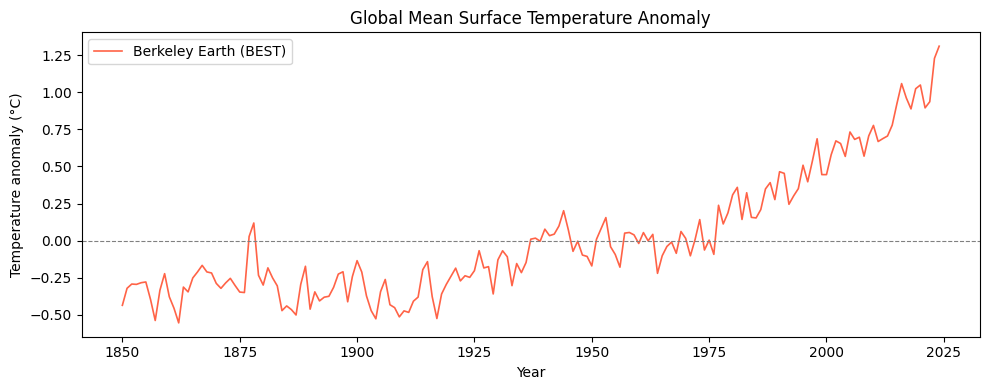

In [4]:
# =============================================================
# 💡 EXAMPLE — A complete matplotlib figure
# =============================================================

fig, ax = plt.subplots(figsize=(10, 4))   # create a blank figure and axes

ax.plot(best["Year"], best["Anomaly"],    # x-axis: years, y-axis: temperature anomaly
        color="tomato", linewidth=1.2,
        label="Berkeley Earth (BEST)")

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")  # reference line at 0

ax.set_title("Global Mean Surface Temperature Anomaly")      # title of the plot
ax.set_xlabel("Year")                                        # label on the x-axis
ax.set_ylabel("Temperature anomaly (°C)")                    # label on the y-axis
ax.legend()                                                  # show the legend

plt.tight_layout()
plt.show()

> 💬 **Discussion:** What patterns do you notice? When does the warming really start accelerating?

---

## 3) Comparing two datasets

BEST and GISTEMP are produced by different scientific teams using different methods. Do they agree?

The example below shows how to add a **second line** and a **legend** to a plot.

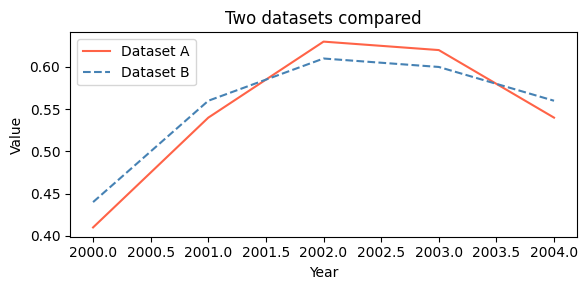

In [5]:
# =============================================================
# 💡 EXAMPLE — Adding a second line and legend
# =============================================================
# Suppose we have two data series, A and B:

years_example = [2000, 2001, 2002, 2003, 2004]
series_A = [0.41, 0.54, 0.63, 0.62, 0.54]
series_B = [0.44, 0.56, 0.61, 0.60, 0.56]

fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(years_example, series_A, color="tomato",  label="Dataset A")
ax.plot(years_example, series_B, color="steelblue", label="Dataset B", linestyle="--")

ax.set_title("Two datasets compared")
ax.set_xlabel("Year")
ax.set_ylabel("Value")
ax.legend()   # <-- shows the labels we gave to each plot() call

plt.tight_layout()
plt.show()

### 🖊️ Your turn: overlay GISTEMP on the BEST record

Copy the structure from the example above. You already have:
- `best["Year"]` and `best["Anomaly"]` for the BEST data
- `gistemp["Year"]` and `gistemp["Anomaly"]` for GISTEMP

**Tasks:**
1. Plot BEST in red (`color="tomato"`) and GISTEMP in blue (`color="steelblue"`)
2. Add a title, x-label, y-label, and legend
3. Add the `axhline` at zero (copy it from the example above!)

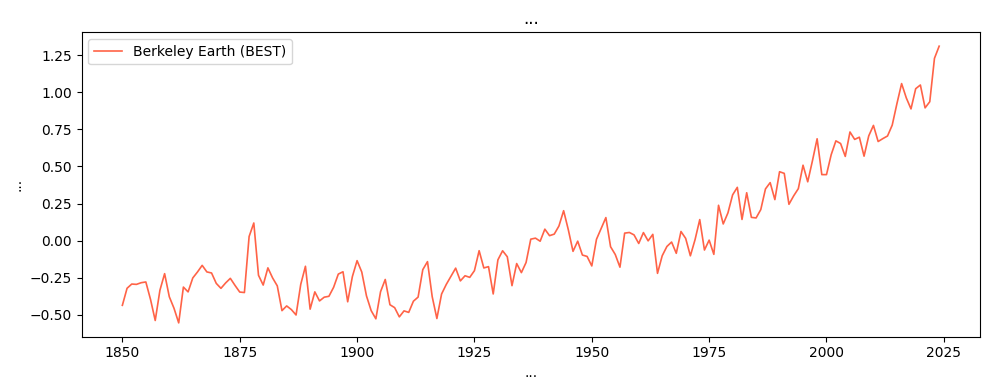

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot BEST — already done for you:
ax.plot(best["Year"], best["Anomaly"], color="tomato", linewidth=1.2, label="Berkeley Earth (BEST)")

# ✏️ Add the GISTEMP line below:
# ax.plot( ... )

# ✏️ Add an axhline at y=0:
# ax.axhline( ... )

# ✏️ Add title, axis labels, and legend:
ax.set_title("...")
ax.set_xlabel("...")
ax.set_ylabel("...")
ax.legend()

plt.tight_layout()
plt.show()

> 💬 **Discussion:** Do the two datasets agree with each other? Would you trust them more or less because of this?

---

## (OPTIONAL) 4) Smoothing noisy data

Year-to-year temperature varies a lot due to natural events like El Niño. A **moving average** smooths out short-term noise to reveal the underlying trend.

The example below shows a 10-year moving average — each point becomes the average of the surrounding 10 years.

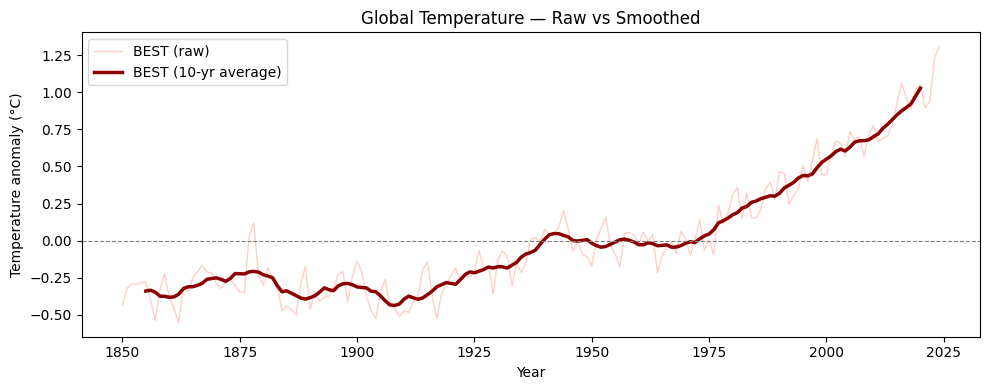

In [5]:
# 10-year moving average (rolling mean)
best_smooth = best["Anomaly"].rolling(window=10, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(best["Year"], best["Anomaly"],
        color="tomato", alpha=0.3, linewidth=1, label="BEST (raw)")
ax.plot(best["Year"], best_smooth,
        color="darkred", linewidth=2.5, label="BEST (10-yr average)")

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Global Temperature — Raw vs Smoothed")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature anomaly (°C)")
ax.legend()

plt.tight_layout()
plt.show()

> 💬 **Discussion:** Why does smoothing help us understand the trend? What information do we lose when we smooth?

---

# PART II — Temperature is rising. What is driving these changes?

We see a clear warming trend. But *why* is it happening? Let's examine the most common proposed explanations one by one.

---

## 1) Has the sun become dramatically brighter?

The sun's energy output is called **Total Solar Irradiance (TSI)**. It follows an 11-year cycle of sunspot activity. In the distant past, grand solar minima (prolonged periods of low activity) contributed to cooling events like the *Little Ice Age*.

Let's look at the data from NOAA's satellite record.

In [7]:
# --- Load Total Solar Irradiance (NOAA, one file per year) ---
tsi_files = sorted(glob.glob(str(RAW_DIR / "NOAA" / "tsi_*.nc")))

tsi_list = []
for f in tsi_files:
    ds = xr.open_dataset(f)
    tsi_list.append(ds[["TSI"]].load())
    ds.close()

tsi = xr.concat(tsi_list, dim="time")

# Compute yearly mean
tsi_yearly = tsi["TSI"].resample(time="YE").mean()

print(f"TSI record: {int(tsi_yearly.time.dt.year[0])} – {int(tsi_yearly.time.dt.year[-1])}")

TSI record: 1875 – 2025


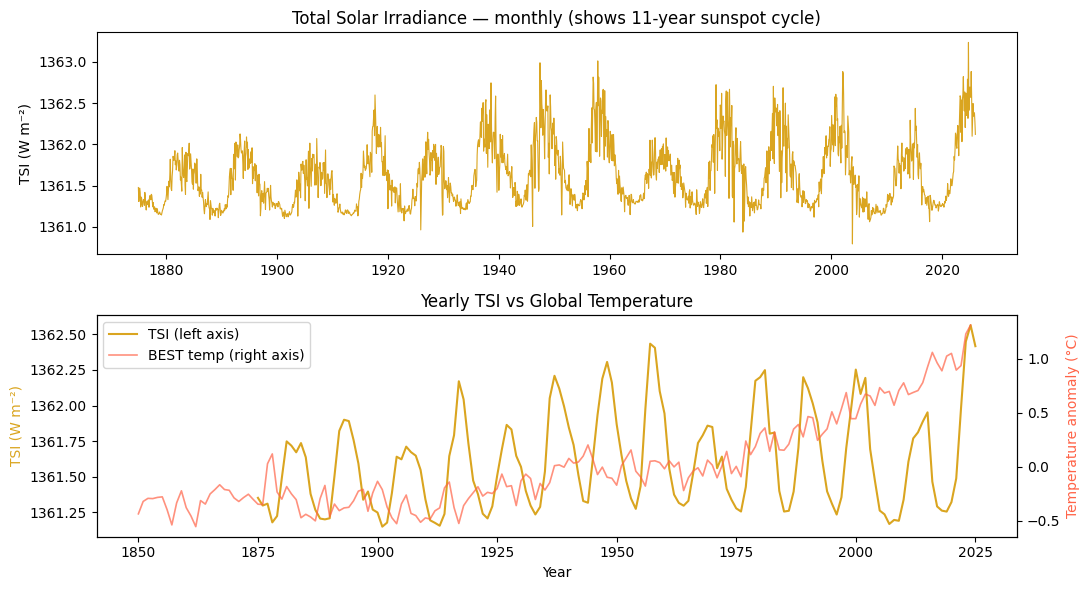

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)

# Top panel: monthly TSI showing the 11-year cycle
axes[0].plot(tsi["time"], tsi["TSI"], color="goldenrod", linewidth=0.8)
axes[0].set_title("Total Solar Irradiance — monthly (shows 11-year sunspot cycle)")
axes[0].set_ylabel("TSI (W m⁻²)")

# Bottom panel: yearly TSI alongside the BEST temperature anomaly
ax_tsi = axes[1]
ax_temp = ax_tsi.twinx()   # second y-axis on the right

ax_tsi.plot(tsi_yearly.time.dt.year, tsi_yearly.values,
            color="goldenrod", linewidth=1.5, label="TSI (left axis)")
ax_temp.plot(best["Year"], best["Anomaly"],
             color="tomato", linewidth=1.2, alpha=0.7, label="BEST temp (right axis)")

ax_tsi.set_title("Yearly TSI vs Global Temperature")
ax_tsi.set_xlabel("Year")
ax_tsi.set_ylabel("TSI (W m⁻²)", color="goldenrod")
ax_temp.set_ylabel("Temperature anomaly (°C)", color="tomato")

lines1, labels1 = ax_tsi.get_legend_handles_labels()
lines2, labels2 = ax_temp.get_legend_handles_labels()
ax_tsi.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

> 💬 **Discussion:** Does the long-term trend in solar output match the warming trend?

---

## 2) Have volcanoes changed Earth's temperature?

Large volcanic eruptions inject tiny particles (aerosols) into the upper atmosphere, where they reflect incoming sunlight and **temporarily cool** the planet. The most dramatic recent examples:

- **1963** — Mount Agung (Indonesia)
- **1982** — El Chichón (Mexico)
- **1991** — Mount Pinatubo (Philippines! )

We use the **Sato–Lacis Aerosol Optical Depth (AOD)** dataset from NASA GISS — a measure of how much light the stratospheric aerosols block.

In [9]:
# --- Load stratospheric AOD (Sato-Lacis, NASA GISS) ---
aod_ds = xr.open_dataset(RAW_DIR / "NASA" / "sato_lacis_aod.nc")

# tau_lvl has dims (month, level, lat)
# Sum over altitude levels → total column AOD
# Average over latitude (simple mean; a proper area-weighting would use cos(lat))
aod_global = aod_ds["tau_lvl"].sum("level").mean("lat")

# Convert the time coordinate to actual dates
time_dates = pd.to_datetime(aod_ds["month"].values)
aod_years = time_dates.year + (time_dates.month - 1) / 12

print(f"AOD record: {time_dates[0].year} – {time_dates[-1].year}")


AOD record: 1850 – 2022


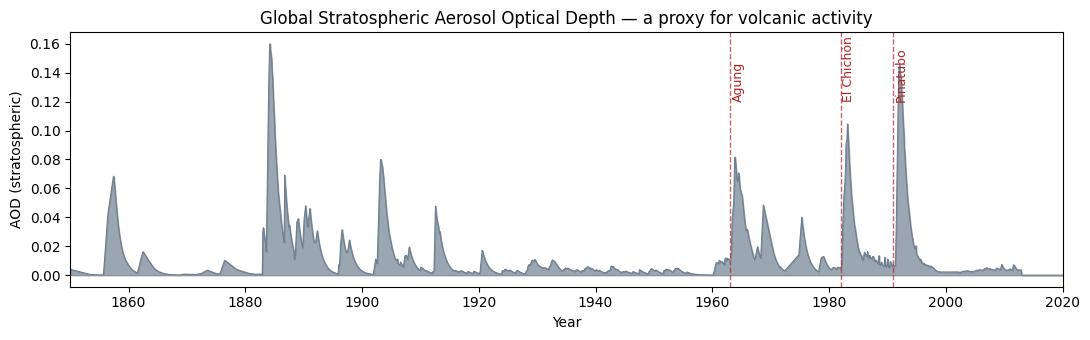

In [10]:
fig, ax = plt.subplots(figsize=(11, 3.5))

ax.fill_between(aod_years, aod_global.values, color="slategray", alpha=0.7)
ax.plot(aod_years, aod_global.values, color="slategray", linewidth=0.8)

# Annotate the three major eruptions
for year, name in [(1963, "Agung"), (1982, "El Chichón"), (1991, "Pinatubo")]:
    ax.axvline(year, color="firebrick", linewidth=1, linestyle="--", alpha=0.7)
    ax.text(year + 0.3, aod_global.values.max() * 0.75, name,
            color="firebrick", fontsize=9, rotation=90, va="bottom")

ax.set_title("Global Stratospheric Aerosol Optical Depth — a proxy for volcanic activity")
ax.set_xlabel("Year")
ax.set_ylabel("AOD (stratospheric)")
ax.set_xlim(1850, 2020)

plt.tight_layout()
plt.show()

> 💬 **Discussion:** Do you see sudden spikes after major eruptions? Could volcanoes explain the *long-term warming trend*?

---

## 3) Is it ENSO's fault?

The **El Niño–Southern Oscillation (ENSO)** is the most powerful year-to-year climate driver on Earth. During **El Niño** years, warm water in the Pacific spreads eastward, raising global temperatures. During **La Niña**, the opposite happens.

The strength of ENSO is measured by the **Niño 3.4 index** — the average sea-surface temperature anomaly over the central-eastern equatorial Pacific.

Below is a complete example showing how to plot the ENSO index. Then you'll create a combined figure.

In [11]:
# --- Load ENSO (Niño 3.4 index, KNMI Climate Explorer) ---
nino_ds = xr.open_dataset(RAW_DIR / "NOAA" / "nino.nc",
                           decode_times=False)     # time needs manual fixing

# The time axis is stored as 'months since 1854-01-15' in float format
nino_ds["time"] = (
    pd.date_range(start="1854-01-01", periods=nino_ds.sizes["time"], freq="MS")
    + pd.Timedelta(days=14)
)

nino = nino_ds["Nino3.4r"]

# Yearly mean
nino_df = pd.DataFrame({"date": nino_ds["time"].values, "enso": nino.values})
nino_df["Year"] = pd.DatetimeIndex(nino_df["date"]).year
nino_yearly = nino_df.groupby("Year")["enso"].mean().reset_index()

print(f"ENSO record: {nino_yearly['Year'].min()} – {nino_yearly['Year'].max()}")

ENSO record: 1854 – 2026


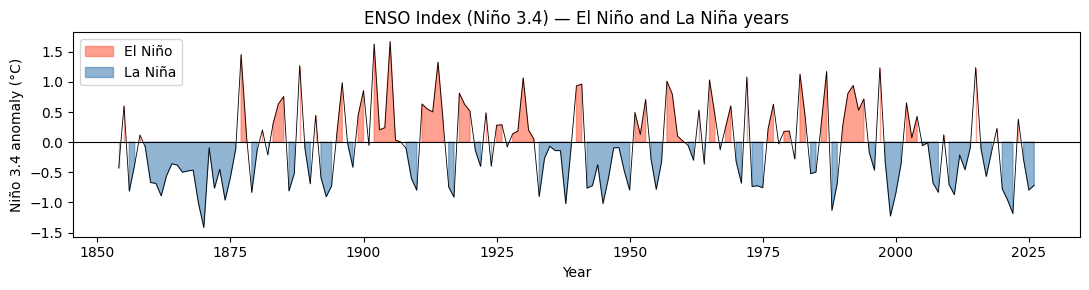

In [12]:
# =============================================================
# 💡 EXAMPLE — Colouring above/below zero using fill_between
# =============================================================

fig, ax = plt.subplots(figsize=(11, 3))

years = nino_yearly["Year"]
enso  = nino_yearly["enso"]

# Shade positive (El Niño) years red, negative (La Niña) years blue
ax.fill_between(years, enso, 0,
                where=(enso > 0), color="tomato",    alpha=0.6, label="El Niño")
ax.fill_between(years, enso, 0,
                where=(enso < 0), color="steelblue", alpha=0.6, label="La Niña")
ax.plot(years, enso, color="black", linewidth=0.6)
ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("ENSO Index (Niño 3.4) — El Niño and La Niña years")
ax.set_xlabel("Year")
ax.set_ylabel("Niño 3.4 anomaly (°C)")
ax.legend()

plt.tight_layout()
plt.show()

### 🖊️ Your turn: ENSO vs global temperature

Make a two-panel figure:
- **Top panel:** The ENSO index (copy + adjust from the example above)
- **Bottom panel:** The BEST global temperature anomaly

Use `sharex=True` so the x-axes are linked, and limit both panels to the same time period using `ax.set_xlim(1880, 2024)`. This lets you visually compare whether warm (El Niño) years match warm temperature anomalies.

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

# --- Top panel: ENSO index ---
ax_enso = axes[0]
# ✏️ Copy and adapt the fill_between plot from the example:
# ax_enso.fill_between( ... )
# ax_enso.fill_between( ... )
# ax_enso.axhline( ... )
ax_enso.set_ylabel("Niño 3.4 (°C)")
ax_enso.set_title("ENSO Index vs Global Temperature")

# --- Bottom panel: BEST temperature ---
ax_temp = axes[1]
# ✏️ Plot the BEST temperature anomaly (see PART I for how):
# ax_temp.plot( ... )
ax_temp.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax_temp.set_ylabel("Temperature anomaly (°C)")
ax_temp.set_xlabel("Year")

# Zoom into the overlapping period
ax_temp.set_xlim(1880, 2024)

plt.tight_layout()
plt.show()

> 💬 **Discussion:** Do El Niño years (red) tend to coincide with temperature peaks? Can ENSO alone explain the long-term upward trend?

---

## 4) What about CO₂?

Carbon dioxide (CO₂) is a **greenhouse gas**: it absorbs outgoing infrared radiation and re-emits it in all directions, trapping heat in the atmosphere. Since the Industrial Revolution (~1850), humans have burned fossil fuels, releasing large amounts of CO₂.

The **Keeling Curve** is the longest continuous record of atmospheric CO₂, measured at the Mauna Loa Observatory in Hawaii since 1958 by Charles Keeling.

In [13]:
# --- Load Mauna Loa CO₂ (NOAA Global Monitoring Laboratory) ---
co2 = pd.read_csv(
    RAW_DIR / "NOAA" / "mauna_loa_co2.csv",
    comment="#",
)
# Monthly averages; -99.99 is the missing-value flag
co2 = co2[co2["average"] > 0].copy()

# Yearly mean
co2_yearly = co2.groupby("year")["average"].mean().reset_index()

co2.head()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


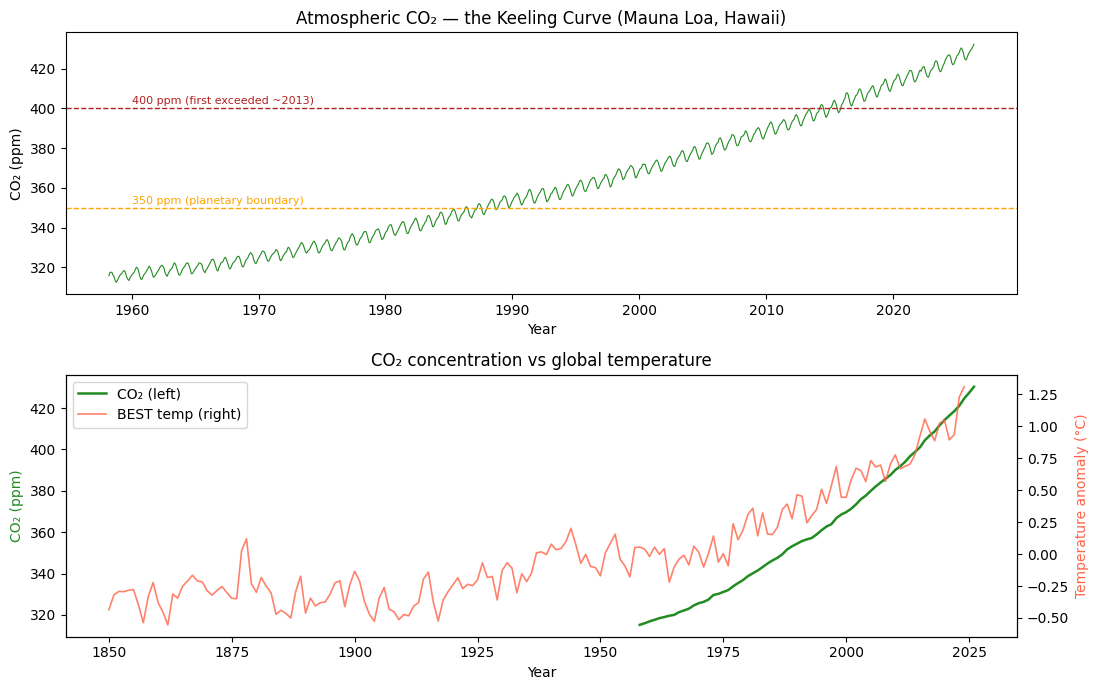

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

# --- Top panel: Keeling Curve ---
ax_co2 = axes[0]
ax_co2.plot(co2["decimal date"], co2["average"],
            color="forestgreen", linewidth=0.8)
ax_co2.set_title("Atmospheric CO₂ — the Keeling Curve (Mauna Loa, Hawaii)")
ax_co2.set_ylabel("CO₂ (ppm)")
ax_co2.set_xlabel("Year")

# Annotate the 350 ppm threshold (often cited as a planetary boundary)
ax_co2.axhline(350, color="orange", linewidth=1, linestyle="--")
ax_co2.text(1960, 352, "350 ppm (planetary boundary)", color="orange", fontsize=8)

# Annotate 400 ppm crossed for first time
ax_co2.axhline(400, color="firebrick", linewidth=1, linestyle="--")
ax_co2.text(1960, 402, "400 ppm (first exceeded ~2013)", color="firebrick", fontsize=8)

# --- Bottom panel: CO₂ and temperature on the same time axis ---
ax_co2b = axes[1]
ax_temp2 = ax_co2b.twinx()

ax_co2b.plot(co2_yearly["year"], co2_yearly["average"],
             color="forestgreen", linewidth=1.8, label="CO₂ (left)")
ax_temp2.plot(best["Year"], best["Anomaly"],
              color="tomato", linewidth=1.2, alpha=0.8, label="BEST temp (right)")

ax_co2b.set_title("CO₂ concentration vs global temperature")
ax_co2b.set_xlabel("Year")
ax_co2b.set_ylabel("CO₂ (ppm)", color="forestgreen")
ax_temp2.set_ylabel("Temperature anomaly (°C)", color="tomato")

lines1, labels1 = ax_co2b.get_legend_handles_labels()
lines2, labels2 = ax_temp2.get_legend_handles_labels()
ax_co2b.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

> 💬 **Discussion:** Notice the small wiggles in the monthly CO₂ record. What causes the regular annual up-down oscillation? *(Hint: think about seasons and photosynthesis.)*

---

## 5) Correlation vs causation ⚠️

CO₂ and temperature track each other very closely. Let's make a scatter plot to visualise this correlation.

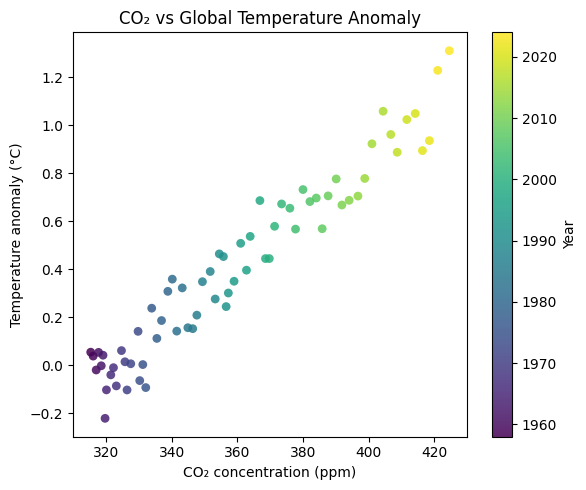

In [15]:
# Merge CO₂ and BEST on year (only keep years present in both datasets)
merged = co2_yearly.merge(best, left_on="year", right_on="Year", how="inner")

fig, ax = plt.subplots(figsize=(6, 5))

scatter = ax.scatter(merged["average"], merged["Anomaly"],
                     c=merged["year"], cmap="viridis",
                     s=40, edgecolors="none", alpha=0.85)
plt.colorbar(scatter, ax=ax, label="Year")

ax.set_title("CO₂ vs Global Temperature Anomaly")
ax.set_xlabel("CO₂ concentration (ppm)")
ax.set_ylabel("Temperature anomaly (°C)")

plt.tight_layout()
plt.show()

The correlation between CO₂ and temperature is striking. But does correlation mean causation?

Consider this: the number of Nicolas Cage films released per year also correlates with drowning deaths in swimming pools. Also: popularity of the first name Brooklyn correlates with UFO sightings in Kentucky.

Check out some more spurious correlations 👉 https://www.tylervigen.com/spurious-correlations

So why *do* scientists confidently say CO₂ causes warming?

1. **Physical mechanism**: We have understood the greenhouse effect since the 1850s (Eunice Newton Foote, John Tyndall). CO₂ *provably* absorbs infrared radiation in laboratory experiments.
2. **Directionality**: Isotopic analysis of atmospheric CO₂ shows it is fossil in origin — the fingerprint of human emissions.
3. **Ruling out alternatives**: We have just seen that the sun and volcanoes cannot explain the long-term trend, and ENSO only causes year-to-year variation.

> 💬 **Discussion:** Which of these three points do you find most convincing? Why?

---

## *"But CO2 fluctuates naturally, it's not actually human's fault!"*

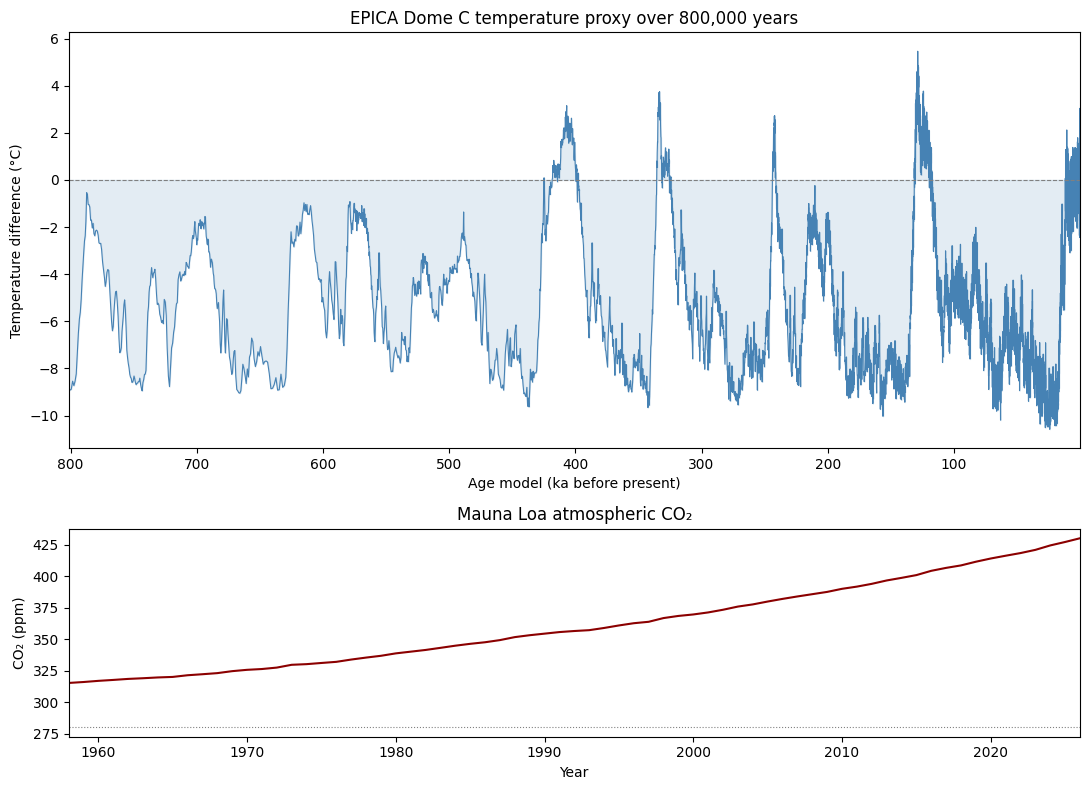

In [16]:
# --- Load the EPICA Dome C ice-core data ---
epica = pd.read_csv(
    RAW_DIR / "EPICA" / "epica_dome_c.txt",
    sep="\t",
    skiprows=20,
    na_values=[""],
)
epica.columns = ["depth_m", "age_ka", "dD_permil", "delta_t_c", "sample_id"]
epica = epica.dropna(subset=["age_ka", "delta_t_c"]).copy()

# --- Build a combined figure with EPICA and Mauna Loa ---
co2_plot = co2_yearly.copy()
if "year" not in co2_plot.columns:
    co2_plot = co2_plot.reset_index()
co2_plot = co2_plot[co2_plot["average"] > 0].copy()

fig, (ax_epica, ax_co2) = plt.subplots(
    2, 1, figsize=(11, 8), gridspec_kw={"height_ratios": [2, 1]}
)

ax_epica.plot(
    epica["age_ka"],
    epica["delta_t_c"],
    color="steelblue",
    linewidth=0.8,
)
ax_epica.fill_between(
    epica["age_ka"],
    epica["delta_t_c"],
    0,
    color="steelblue",
    alpha=0.15,
)
ax_epica.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax_epica.set_xlim(epica["age_ka"].max(), epica["age_ka"].min())
ax_epica.set_title("EPICA Dome C temperature proxy over 800,000 years")
ax_epica.set_ylabel("Temperature difference (°C)")
ax_epica.set_xlabel("Age model (ka before present)")

ax_co2.plot(
    co2_plot["year"],
    co2_plot["average"],
    color="darkred",
    linewidth=1.5,
)
ax_co2.axhline(280, color="gray", linewidth=0.8, linestyle=":")
ax_co2.set_title("Mauna Loa atmospheric CO₂")
ax_co2.set_xlabel("Year")
ax_co2.set_ylabel("CO₂ (ppm)")
ax_co2.set_xlim(co2_plot["year"].min(), co2_plot["year"].max())

plt.tight_layout()
plt.show()

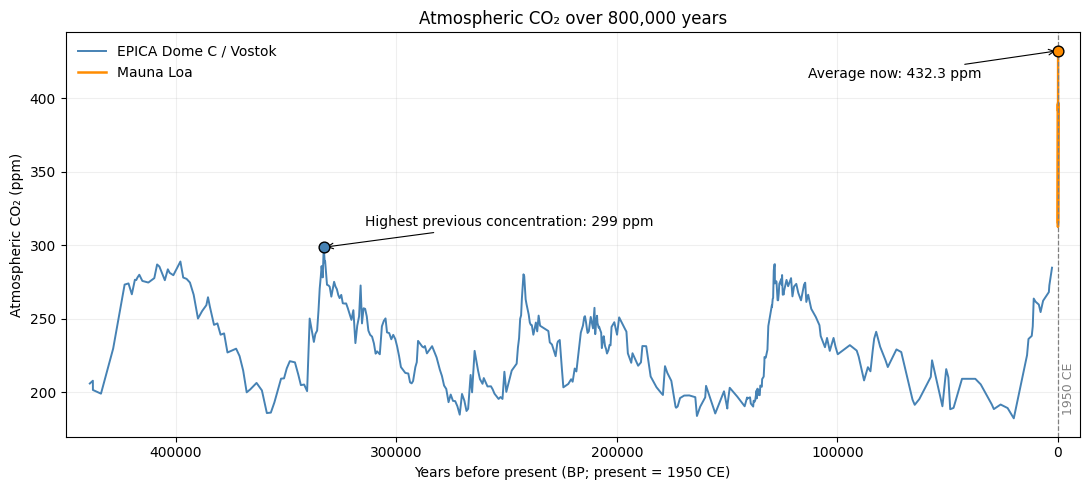

In [17]:
# --- Vostok Dome C CO2 record plus Mauna Loa extension ---
vostok = pd.read_csv(
    RAW_DIR / "NOAA" / "vostok-edc3-co2-2008-noaa.txt",
    sep="\t",
    skiprows=482,
)
vostok.columns = ["depth_m", "gas_age_bp", "co2_ppm"]
vostok = vostok.dropna(subset=["gas_age_bp", "co2_ppm"]).copy()
vostok["gas_age_bp"] = pd.to_numeric(vostok["gas_age_bp"], errors="coerce")
vostok["co2_ppm"] = pd.to_numeric(vostok["co2_ppm"], errors="coerce")
vostok = vostok.dropna(subset=["gas_age_bp", "co2_ppm"]).sort_values("gas_age_bp")

mauna_loa = pd.read_csv(RAW_DIR / "NOAA" / "mauna_loa_co2.csv", comment="#")
mauna_loa = mauna_loa[mauna_loa["average"] > 0].copy()
mauna_loa["bp"] = 1950 - mauna_loa["decimal date"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(vostok["gas_age_bp"], vostok["co2_ppm"],
        color="steelblue", linewidth=1.4, label="EPICA Dome C / Vostok")
ax.plot(mauna_loa["bp"], mauna_loa["average"],
        color="darkorange", linewidth=1.8, label="Mauna Loa")

ax.axvline(0, color="gray", linewidth=0.9, linestyle="--")
ax.text(-2000, ax.get_ylim()[0] + 15, "1950 CE", color="gray", fontsize=9,
        rotation=90, va="bottom")

# Find maxima
vostok_max = vostok.loc[vostok["co2_ppm"].idxmax()]
mauna_max = mauna_loa.loc[mauna_loa["average"].idxmax()]

# Highlight maxima
ax.scatter(
    vostok_max["gas_age_bp"], vostok_max["co2_ppm"],
    s=60, color="steelblue", edgecolor="black", zorder=5
)

ax.scatter(
    mauna_max["bp"], mauna_max["average"],
    s=60, color="darkorange", edgecolor="black", zorder=5
)

# Annotate maxima
ax.annotate(
    f'Highest previous concentration: {vostok_max["co2_ppm"]:.0f} ppm',
    xy=(vostok_max["gas_age_bp"], vostok_max["co2_ppm"]),
    xytext=(30, 15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=0.8),
)

ax.annotate(
    f'Average now: {mauna_max["average"]:.1f} ppm',
    xy=(mauna_max["bp"], mauna_max["average"]),
    xytext=(-180, -20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=0.8),
)

ax.set_xlim(vostok["gas_age_bp"].max(), mauna_loa["bp"].min())
ax.set_xlabel("Years before present (BP; present = 1950 CE)")
ax.set_ylabel("Atmospheric CO₂ (ppm)")
ax.set_title("Atmospheric CO₂ over 800,000 years")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
ax.set_xlim(450000, -10000)

plt.tight_layout()
plt.show()

---

## *"So what? It's just a couple of degrees, and I don't care about polar bears either way. They're mean and eat cute seals."*

For the Philippines, even small shifts in global average temperature translate into:

- 🌊 **Sea level rise** — thermal expansion + glacier melt threatens low-lying coastal areas
- 🌀 **Stronger typhoons** — warmer oceans provide more energy; Haiyan (Yolanda, 2013) made landfall with winds over 300 km/h
- 🌧️ **More extreme rainfall** — warmer air holds more moisture, intensifying floods
- 🌾 **Heat stress on crops** — rice yield drops sharply above 35°C

In **Part III** we will zoom into the Philippines and Negros to make this concrete.

---

# PART III — Climate in Negros and the Philippines

## 1) What is 'climate'?

According to Wikipedia: *"Climate is the long-term weather pattern in a region, typically averaged over 30 years."*

The standard reference period used today is **1991–2020**. Let's look at the average temperature and precipitation across the Philippines during that period using **ERA5** — the best global atmospheric reanalysis dataset, produced by the European Centre for Medium-Range Weather Forecasts (ECMWF).

In [18]:
# --- Load ERA5 climatology for the Philippines (1991–2020) ---
# Temperature: 4 readings per day in Kelvin → convert to °C
# Precipitation: daily total in metres → convert to mm/day

print("Loading ERA5 temperature climatology (1991–2020)...")
t2m_clim_files = sorted(glob.glob(str(RAW_DIR / "ERA5" / "2m_temperature" / "t2m_philippines_*.nc")))
t2m_clim_files = [f for f in t2m_clim_files if 1991 <= int(f.split("_")[-1][:4]) <= 2020]

ds_t2m_clim = xr.open_mfdataset(t2m_clim_files, combine="by_coords",
                                  drop_variables=["number"])
t2m_mean = (ds_t2m_clim["t2m"].mean("valid_time") - 273.15).compute()

print("Loading ERA5 precipitation climatology (1991–2020)...")
tp_clim_files = sorted(glob.glob(str(RAW_DIR / "ERA5" / "precipitation" / "tp_philippines_*.nc")))
tp_clim_files = [f for f in tp_clim_files if 1991 <= int(f.split("_")[-1][:4]) <= 2020]

ds_tp_clim = xr.open_mfdataset(tp_clim_files, combine="by_coords",
                                 drop_variables=["number"])
# Convert m/day → mm/day, then to mm/year
tp_mean_annual = (ds_tp_clim["tp"].mean("valid_time") * 1000 * 365).compute()

print("Done!")

Loading ERA5 temperature climatology (1991–2020)...
Loading ERA5 precipitation climatology (1991–2020)...
Done!


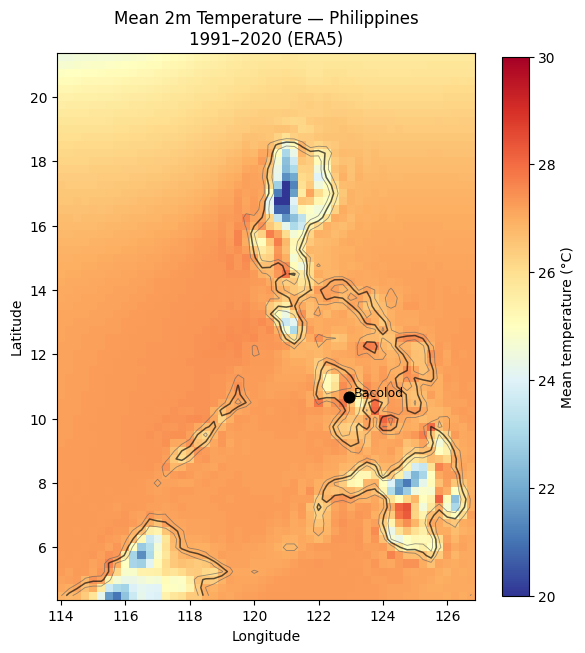

In [22]:
# =============================================================
# 💡 EXAMPLE — A 2D map of mean temperature over the Philippines
# =============================================================

lats = t2m_mean.latitude.values
lons = t2m_mean.longitude.values
lsm = xr.open_dataset(RAW_DIR / "ERA5" / "land_sea_mask" / "land_sea_mask_2024-01-01T00.nc")["land_sea_mask"].sel(latitude=lats, longitude=lons)

fig, ax = plt.subplots(figsize=(6, 8))

im = ax.pcolormesh(lons, lats, t2m_mean.values,
                   cmap="RdYlBu_r",                    # red = warm, blue = cool
                   vmin=20, vmax=30)                   # temperature range in °C

ax.contour(lsm.longitude, lsm.latitude, lsm.values,
           levels=[0.25, 0.5, 0.75],
           colors=["#666666", "#111111", "#666666"],
           linewidths=[0.6, 1.1, 0.6], alpha=0.7, zorder=4)

plt.colorbar(im, ax=ax, label="Mean temperature (°C)", shrink=0.7)

# Mark Bacolod
ax.scatter(122.95, 10.68, color="black", s=60, zorder=5)
ax.text(123.1, 10.68, "Bacolod", fontsize=9)

ax.set_title("Mean 2m Temperature — Philippines\n1991–2020 (ERA5)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

> 💬 **Discussion:** Which regions are warmest? Which are coolest? Can you explain the pattern?

---

### 🖊️ Your turn: precipitation map

Using the temperature map above as a template, make the same kind of map for **mean annual precipitation** (`tp_mean_annual`). 

**Tips:**
- Use `cmap="YlGnBu"` (yellow = dry, blue = wet)
- The precipitation range is roughly 500–5000 mm/year; set `vmin=500, vmax=5000`
- Change the colorbar label to `"Mean annual precipitation (mm/yr)"`

In [ ]:
fig, ax = plt.subplots(figsize=(6, 8))

# ✏️ Create the pcolormesh for tp_mean_annual:
# im = ax.pcolormesh( ... )

# ✏️ Add the colorbar:
# plt.colorbar( ... )

# ✏️ Mark Bacolod:
# ax.scatter( ... )
# ax.text( ... )

ax.set_title("Mean Annual Precipitation — Philippines\n1991–2020 (ERA5)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

> 💬 **Discussion:** Which regions are wettest? Driest? Why might the eastern and western sides of islands differ so strongly?

---

## 2) What climate does Bacolod have?

We'll extract temperature and precipitation data for **Bacolod** (10.68°N, 122.95°E) and look at:
1. The long-term temperature trend (1940–2024)
2. The typical annual cycle of temperature and rainfall (the *climatological* monthly means over 1991–2020)

In [23]:
# --- Extract Bacolod time series (lazily — only one grid point loaded) ---
BACOLOD_LAT = 10.68
BACOLOD_LON = 122.95

print("Loading Bacolod temperature time series (1940–2024)...")
all_t2m_files = sorted(glob.glob(str(RAW_DIR / "ERA5" / "2m_temperature" / "t2m_philippines_*.nc")))
ds_t2m_all = xr.open_mfdataset(all_t2m_files, combine="by_coords",
                                 drop_variables=["number"])

t2m_bacolod = (ds_t2m_all["t2m"]
               .sel(latitude=BACOLOD_LAT, longitude=BACOLOD_LON, method="nearest")
               - 273.15)

# Yearly mean and monthly climatology
t2m_yearly   = t2m_bacolod.groupby("valid_time.year").mean().compute()
t2m_monthly  = (t2m_bacolod
                .sel(valid_time=slice("1991", "2020"))
                .groupby("valid_time.month").mean().compute())

print("Loading Bacolod precipitation time series (1940–2024)...")
all_tp_files = sorted(glob.glob(str(RAW_DIR / "ERA5" / "precipitation" / "tp_philippines_*.nc")))
ds_tp_all = xr.open_mfdataset(all_tp_files, combine="by_coords",
                                drop_variables=["number"])

tp_bacolod = (ds_tp_all["tp"]
              .sel(latitude=BACOLOD_LAT, longitude=BACOLOD_LON, method="nearest")
              * 1000)  # m/day → mm/day

tp_monthly  = (tp_bacolod
               .sel(valid_time=slice("1991", "2020"))
               .groupby("valid_time.month").mean().compute())

print("Done!")

Loading Bacolod temperature time series (1940–2024)...
Loading Bacolod precipitation time series (1940–2024)...
Done!


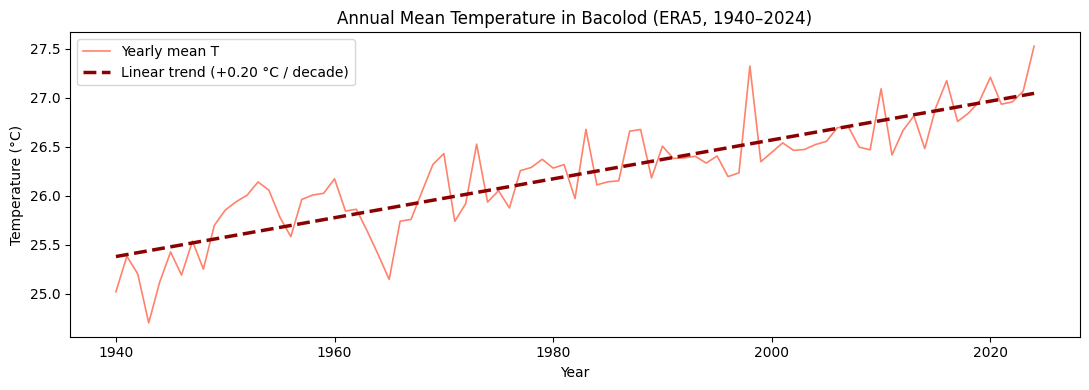

In [24]:
# --- Long-term temperature trend in Bacolod ---
years = t2m_yearly["year"].values
temps = t2m_yearly.values

# Fit a linear trend
trend_coeffs = np.polyfit(years, temps, 1)
trend_line   = np.polyval(trend_coeffs, years)
warming_per_decade = trend_coeffs[0] * 10

fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(years, temps, color="tomato", linewidth=1.2, alpha=0.8, label="Yearly mean T")
ax.plot(years, trend_line, color="darkred", linewidth=2.5, linestyle="--",
        label=f"Linear trend (+{warming_per_decade:.2f} °C / decade)")

ax.set_title("Annual Mean Temperature in Bacolod (ERA5, 1940–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.legend()

plt.tight_layout()
plt.show()

> 💬 **Discussion:** How does the warming rate in Bacolod compare to the global average (~0.18 °C/decade since 1981)?

---

Now let's look at the **annual cycle** — the typical pattern of temperature and rainfall throughout the year. This is what characterises a place's *climate*.

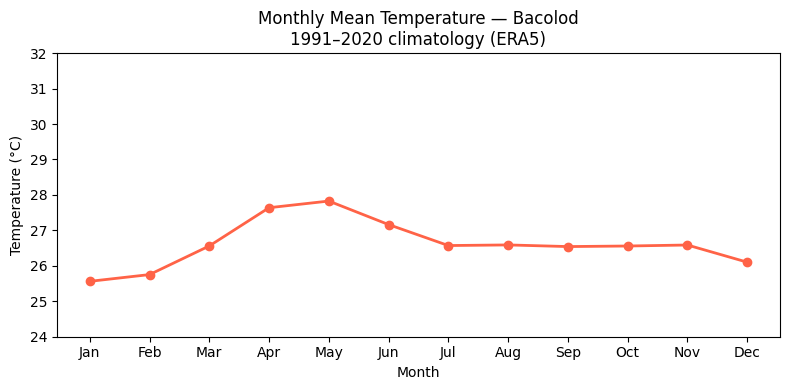

In [25]:
# =============================================================
# 💡 EXAMPLE — Monthly mean temperature (1991–2020 climatology)
# =============================================================

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(1, 13), t2m_monthly.values,
        color="tomato", linewidth=2, marker="o", markersize=6)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylim(24, 32)

ax.set_title("Monthly Mean Temperature — Bacolod\n1991–2020 climatology (ERA5)")
ax.set_xlabel("Month")
ax.set_ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

### 🖊️ Your turn: monthly precipitation

Make the same kind of plot for **monthly mean precipitation** (`tp_monthly`) — the average rainfall for each month of the year.

**Tips:**
- Use bars instead of a line: `ax.bar(range(1, 13), tp_monthly.values, color="steelblue")`
- Set y-axis label to `"Precipitation (mm/day)"`
- Use the same `month_names` list for x-tick labels

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

# ✏️ Make a bar chart of monthly mean precipitation:
# ax.bar( ... )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)

ax.set_title("Monthly Mean Precipitation — Bacolod\n1991–2020 climatology (ERA5)")
ax.set_xlabel("Month")
ax.set_ylabel("Precipitation (mm/day)")

plt.tight_layout()
plt.show()

> 💬 **Discussion:** Which months are wet and which are dry? What drives this seasonal pattern? *(Hint: think about the monsoon and the direction it comes from.)*

---

## 3) What is the Köppen-Geiger climate type of Bacolod?

The **Köppen-Geiger (KG) classification** is the most widely used climate scheme in the world. It was developed by German-Russian climatologist Wladimir Köppen in 1884 — as a botanist, he designed it around the idea that *climate shapes vegetation*. As a result, the KG classes correspond strongly to biomes, making it especially useful in biology.

The system works as a **decision tree**. The five main climate groups are:

| Group | Name | Main criterion |
|-------|------|----------------|
| **A** | Tropical | Coldest month ≥ 18°C |
| **B** | Arid | Precipitation too low for forest |
| **C** | Temperate | Coldest month −3°C to 18°C |
| **D** | Continental | Coldest month < −3°C |
| **E** | Polar | Warmest month < 10°C |

Within **Group A**, the subtypes depend on rainfall seasonality:

| Subtype | Name | Criterion |
|---------|------|----------|
| **Af** | Tropical rainforest | Driest month ≥ 60 mm |
| **Am** | Tropical monsoon | Driest month < 60 mm, but annual P ≥ 25×(100 − driest month in mm) |
| **Aw** | Tropical savanna | Otherwise |

Let's compute the values we need from the ERA5 climatology.

In [26]:
# Values needed for the classification
coldest_month_T  = float(t2m_monthly.min())          # minimum monthly temperature
annual_precip    = float(tp_monthly.sum() * 30.44)   # approx. annual total (mm)
driest_month_P   = float(tp_monthly.min() * 30.44)   # precipitation of driest month (mm)

print(f"Coldest month mean temperature : {coldest_month_T:.1f} °C")
print(f"Annual precipitation           : {annual_precip:.0f} mm")
print(f"Driest month precipitation     : {driest_month_P:.0f} mm")

Coldest month mean temperature : 25.6 °C
Annual precipitation           : 3406 mm
Driest month precipitation     : 145 mm


Now let's write the decision tree in Python. The key tool is the `if / elif / else` structure.

Here's a simple example first:

In [27]:
# =============================================================
# 💡 EXAMPLE — if / elif / else in Python
# =============================================================
temperature = 32

if temperature > 35:
    description = "Dangerously hot"
elif temperature > 30:
    description = "Very warm"
elif temperature > 20:
    description = "Comfortable"
else:
    description = "Cool"

print(f"At {temperature}°C: {description}")

# You can also combine conditions with 'and' / 'or':
driest = 35
annual = 1800

if driest < 60 and annual >= 25 * (100 - driest):
    print("This would be Am (tropical monsoon)")

At 32°C: Very warm
This would be Am (tropical monsoon)


### 🖊️ Your turn: classify Bacolod's climate

Using the three values computed above (`coldest_month_T`, `annual_precip`, `driest_month_P`) and the table of criteria, complete the decision tree below.

Work through the conditions in order:
1. First determine the main group (A, B, C, D, or E)
2. If it is Group A, determine the subtype (Af, Am, or Aw)

In [ ]:
# ✏️ Complete this decision tree:

# Step 1: determine main group
if coldest_month_T >= 18:
    group = "A"   # Tropical
# elif coldest_month_T >= ???:
#     group = "C"   # Temperate
# elif coldest_month_T >= ???:
#     group = "D"   # Continental
# else:
#     group = "E"   # Polar

# Step 2: if Group A, find the subtype
if group == "A":
    if driest_month_P >= 60:
        subtype = "f"   # Af — rainforest
    # elif driest_month_P < 60 and ???:
    #     subtype = "m"   # Am — monsoon
    # else:
    #     subtype = "w"   # Aw — savanna
else:
    subtype = ""   # (we won't classify further for non-A groups today)

climate_code = group + subtype
print(f"Bacolod's Köppen-Geiger climate type: {climate_code}")

> 💬 **Discussion:** According to Wikipedia, the Philippines has five climate types: tropical rainforest, tropical monsoon, tropical savanna, humid subtropical and oceanic. What would you expect for Bacolod? Does your result match?

---

## 4) Climate zones in the Philippines — present and future

To finish, let's zoom out. The Köppen-Geiger system has been applied globally, and researchers have used climate models to project how these zones will shift under continued warming.

Beck et al. (2023) published 1 km resolution KG maps for 1901–2099 based on CMIP6 climate model projections:

> Beck, H. E., McVicar, T. R., Vergopolan, N., Berg, A., Lutsko, N. J., Dufour, A., ... & Miralles, D. G. (2023). High-resolution (1 km) Köppen-Geiger maps for 1901–2099 based on constrained CMIP6 projections. *Scientific Data, 10*(1), 724.

Below is an example of how climate zones across the Philippines might shift by 2100 under a high-emissions scenario. Notice how tropical rainforest areas (Af) may contract, with savanna-type conditions (Aw) expanding as rainfall seasonality increases.

*(Interactive maps and downloads available at: https://www.gloh2o.org/koppen/)*

> 💬 **Final discussion:**
> - What does a shift in Köppen-Geiger zone mean for the ecosystems and agriculture of a region?
> - If Bacolod's climate shifts from Am to Aw, what would change about day-to-day life and biodiversity here?
> - What can individuals, communities, and governments do in response?

---

## Well done!

Today you:
- Loaded and visualised real climate data from NASA, NOAA, and ECMWF
- Saw how different potential climate drivers (sun, volcanoes, ENSO, CO₂) compare to the observed warming trend
- Explored the climate of the Philippines and Bacolod using ERA5 reanalysis data
- Used Python's `if/elif/else` to classify Bacolod according to the Köppen-Geiger system

**Tomorrow (Day 2)** we'll go further into biological data — species distributions, ecological surveys, and what data science can tell us about biodiversity.